In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from tgbs_rs.config.config import BASELINE_START, BASELINE_END, CURRENT_START, CURRENT_END, DRIVE_FOLDER, PRODUCTIVITY_BANDS
from tgbs_rs.config.config_vis import S2_VIS_PARAMS, L8_VIS_PARAMS
from tgbs_rs.preprocessing.hls_preprocessing import get_hls_merged_collection, get_hls_l30_collection, get_hls_s30_collection
from tgbs_rs.utils import build_default_sites_featurecollection, get_sites_geometry
from tgbs_rs.summaries import build_period_composites, reduce_image_over_sites, collection_to_site_timeseries
from tgbs_rs.export_rasters import export_table_to_drive
from tgbs_rs.plotting.plotting_indices import *

In [3]:
# Authenticate and Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project= "charrell-personal")

In [12]:
#Initialize Map
Map = geemap.Map()
Map = geemap.Map(height="800px")

In [4]:
# Build Site Feature Collection
sites_fc = build_default_sites_featurecollection()

In [6]:
# Build HLS Source Collection
hls_col = get_hls_merged_collection(
    aoi=sites_fc,
    start_date=ee.Date(BASELINE_START),
    end_date=ee.Date(CURRENT_END),
)

In [11]:
# Build Annual Multiband Composite
annual_col = build_period_composites(
    collection=hls_col,
    bands=PRODUCTIVITY_BANDS,
    start_date=ee.Date(BASELINE_START),
    end_date=ee.Date(CURRENT_END),
    temporal_scale="annual",
    composite_stat="median"
)

In [13]:
# Reduce each annual image over all sites
annual_site_fc = collection_to_site_timeseries(
    collection=annual_col,
    sites_fc=sites_fc,
    bands=PRODUCTIVITY_BANDS,
    reducer=ee.Reducer.mean(),
    scale=30,
    tile_scale=4
)

In [ ]:
# Export Long ee.FeatureCollection to Drive as CSV
export_table_to_drive(
    collection=annual_site_fc,
    description="tgbs_hls_annual_productivity_sites_2014_2025_full",
    folder=DRIVE_FOLDER,
    fileNamePrefix="tgbs_hls_annual_productivity_sites_2014_2025_full",
    fileFormat="CSV"
)

In [ ]:
annual_long = table_to_long_df(
    r"C:\Users\harre\Repos\CERK\TGBS_Base\outputs\tables\tgbs_hls_annual_productivity_sites_2014_2025_full.csv",
    index_bands=["NIRv", "EVI", "NDVI"],
    period_type="annual",
)

annual_long = add_period_label(
    annual_long,
    baseline_start="2014-01-01",
    baseline_end="2017-12-31",
    current_start="2018-01-01",
    current_end="2025-12-31",
)

nirv_summary = build_site_category_summary(annual_long, "NIRv", "annual")
nirv_ref = build_reference_envelope(annual_long, "NIRv", "annual")
nirv_delta = compute_baseline_current_delta(annual_long, "NIRv", "annual")
nirv_std = compute_standardized_delta(annual_long, "NIRv", "annual")
nirv_trend = compute_trend_stats(annual_long, "NIRv", "annual")

plot_site_timeseries(annual_long, "NIRv", "annual")
plot_focal_vs_groups(annual_long, "NIRv", "annual", envelope="quantile")
plot_baseline_current_bars(annual_long, "NIRv", "annual")
plot_standardized_deltas(annual_long, "NIRv", "annual")
plot_trend_slopes(annual_long, "NIRv", "annual")

,year,focal_site,focal_value,reference_mean,degraded_mean,focal_minus_reference,focal_minus_degraded,band
0,2014,KS Rehab,0.000052,0.000067,0.000056,-0.000015,-0.000004,EVI
1,2015,KS Rehab,0.000072,0.000076,0.000059,-0.000004,0.000013,EVI
2,2016,KS Rehab,0.000053,0.000065,0.000049,-0.000012,0.000003,EVI
3,2017,KS Rehab,0.000053,0.000070,0.000050,-0.000017,0.000003,EVI
4,2018,KS Rehab,0.000069,0.000074,0.000055,-0.000005,0.000014,EVI


,year,focal_site,focal_value,reference_mean,degraded_mean,focal_minus_reference,focal_minus_degraded,band
0,2014,KS Rehab,0.588799,0.763230,0.608133,-0.174430,-0.019333,NDVI
1,2015,KS Rehab,0.706370,0.797222,0.612867,-0.090852,0.093503,NDVI
2,2016,KS Rehab,0.600964,0.756155,0.551055,-0.155191,0.049910,NDVI
3,2017,KS Rehab,0.597801,0.782178,0.561106,-0.184377,0.036695,NDVI
4,2018,KS Rehab,0.744145,0.828128,0.625380,-0.083983,0.118764,NDVI


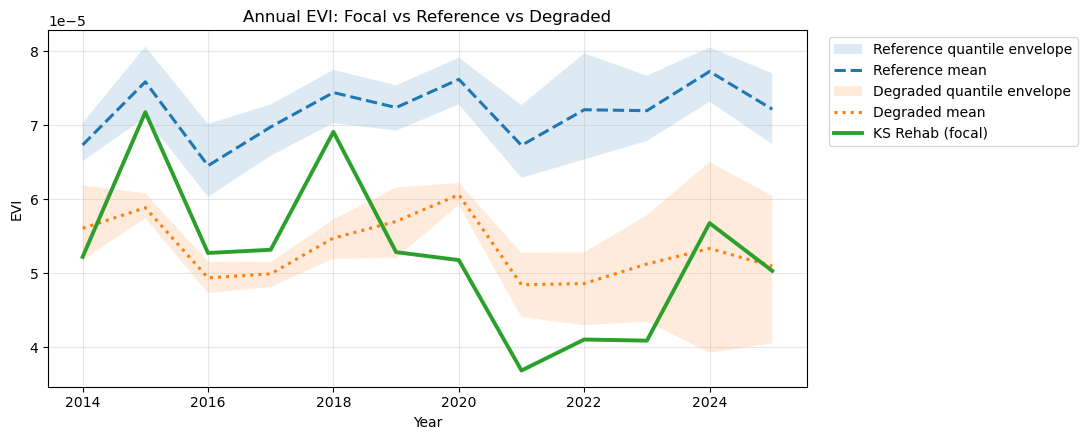

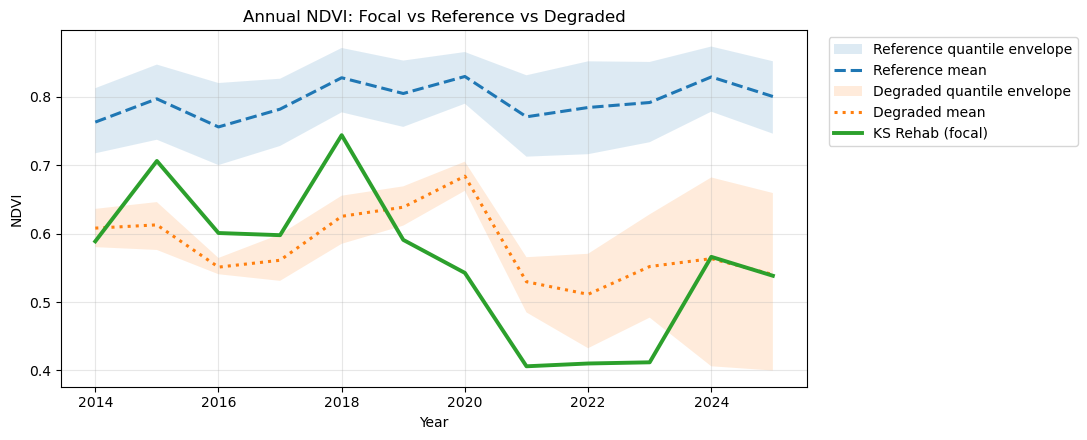

In [8]:
evi_comp = build_focal_comparison_table(annual_long, "EVI")
ndvi_comp = build_focal_comparison_table(annual_long, "NDVI")

display(evi_comp.head())
display(ndvi_comp.head())

plot_focal_vs_groups(annual_long, "EVI", "annual")
plot_focal_vs_groups(annual_long, "NDVI", "annual")